In [2]:
import os
import io
import pandas as pd
import numpy as np
import warnings
import networkx as nx
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from rdkit.Chem.rdMolTransforms import GetAngleDeg
from scipy.spatial import ConvexHull
from os import walk
from ase.io import read, write
# from molgeom import Molecule
from rdkit import Chem
from tqdm import tqdm
from openbabel import openbabel
from molSimplify.Classes import mol3D
from rdkit import RDLogger  

warnings.filterwarnings("ignore")
RDLogger.DisableLog('rdApp.*')   
openbabel.obErrorLog.SetOutputLevel(0)

In [3]:

def find_metal_atom(mol):
    
    
    metal_atom = None
    try:
        if mol is None:
            return metal_atom
        
        # pt = Chem.GetPeriodicTable()
        # common_metals = ['li', 'be', 'na', 'mg', 'al', 'k', 'ca', 'sc', 'ti', 'v', 'cr', 'mn', 'fe', 'co', 'ni', 'cu', 'zn', 'ga', 'rb', 'sr', 'y', 'zr', 'nb', 'mo', 'tc', 'ru', 'rh', 'pd', 'ag', 'cd', 'in', 'sn', 'cs', 'ba', 'la', 'ce', 'pr', 'nd', 'pm', 'sm', 'eu', 'gd', 'tb', 'dy', 'ho', 'er', 'tm', 'yb', 'lu', 'hf', 'ta', 'w', 're', 'os', 'ir', 'pt', 'au', 'hg', 'tl', 'pb', 'bi', 'po', 'fr', 'ra', 'ac', 'th', 'pa', 'u', 'np', 'pu', 'am', 'cm', 'bk', 'cf', 'es', 'fm', 'md', 'no', 'lr', 'rf', 'db', 'sg', 'bh', 'hs', 'mt', 'ds', 'rg', 'cn', 'nh', 'fl', 'mc', 'lv', 'ts', 'og']
        metal_atomic_numbers = {3, 4, 11, 12, 13, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118}
          
        for atom in mol.GetAtoms():
            atomic_num = atom.GetAtomicNum()
            # element_name = pt.GetElementName(atomic_num).lower()
            # General check for common metals, this list can be expanded if needed
            # print(element_name)            
            if atomic_num in metal_atomic_numbers:
                metal_atom = atom
                break
        
    except Exception as ex:
        print(str(ex))
        
    return metal_atom


In [4]:
def draw_3d_molecule_graph_mpl(G):
    """
    Draws a 3D scatter plot of the NetworkX graph using Matplotlib.
    """
    if G is None:
        return

    # Extract positions and labels
    pos = nx.get_node_attributes(G, 'pos')
    symbols = nx.get_node_attributes(G, 'symbol')
    
    # Convert positions to numpy array for plotting
    pos_array = np.array(list(pos.values()))
    x, y, z = pos_array[:, 0], pos_array[:, 1], pos_array[:, 2]

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Plot atoms as scatter points
    ax.scatter(x, y, z, c='b', marker='o', s=100)

    # Label atoms
    for i, (xi, yi, zi) in enumerate(zip(x, y, z)):
        ax.text(xi, yi, zi, f"{symbols[i]} ({i})", color='red')

    # Plot bonds as lines
    for edge in G.edges():
        p1 = np.array(pos[edge[0]])
        p2 = np.array(pos[edge[1]])
        # Draw a line segment
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]], 'gray')

    ax.set_title("3D Molecular Graph Visualization")
    ax.set_xlabel("X Coordinate")
    ax.set_ylabel("Y Coordinate")
    ax.set_zlabel("Z Coordinate")

    # Set the aspect ratio correctly (optional but helpful)
    # The following lines attempt to make the plot look more 'cubic'
    max_range = np.array([x.max()-x.min(), y.max()-y.min(), z.max()-z.min()]).max() / 2.0
    mid_x = (x.max()+x.min()) * 0.5
    mid_y = (y.max()+y.min()) * 0.5
    mid_z = (z.max()+z.min()) * 0.5
    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)

    plt.show()

def draw_3d_molecule_graph_plotly(G):
    """
    Draws a 3D interactive plot of the NetworkX graph using Plotly.
    """
    if G is None:
        return

    pos = nx.get_node_attributes(G, 'pos')
    symbols = nx.get_node_attributes(G, 'symbol')

    # Create Edges Trace
    # We need lists of coordinates for the lines (bonds)
    edge_x = []
    edge_y = []
    edge_z = []
    for edge in G.edges():
        x0, y0, z0 = pos[edge[0]]
        x1, y1, z1 = pos[edge[1]]
        edge_x.extend([x0, x1, None]) # 'None' creates a break between lines
        edge_y.extend([y0, y1, None])
        edge_z.extend([z0, z1, None])

    edge_trace = go.Scatter3d(
        x=edge_x, y=edge_y, z=edge_z,
        line=dict(width=2, color='gray'),
        hoverinfo='none',
        mode='lines')

    # Create Nodes Trace
    # We need lists of coordinates for the markers (atoms)
    node_x = []
    node_y = []
    node_z = []
    node_text = []
    for node in G.nodes():
        x, y, z = pos[node]
        node_x.append(x)
        node_y.append(y)
        node_z.append(z)
        node_text.append(f"Atom Index: {node}<br>Symbol: {symbols[node]}")

    node_trace = go.Scatter3d(
        x=node_x, y=node_y, z=node_z,
        mode='markers',
        hoverinfo='text',
        marker=dict(
            size=10,
            color='skyblue', # Can be customized based on atom type
            colorscale='Viridis',
            opacity=0.8
        ),
        text=node_text
    )

    # Create the Figure object and plot
    fig = go.Figure(data=[edge_trace, node_trace],
                    # layout=go.Layout(
                        # title='<br>Interactive 3D Molecular Visualization (Plotly)',
                        # titlefont_size=16,
                        # showlegend=False,
                        # hovermode='closest',
                        # margin=dict(b=20,l=0,r=0,t=40),
                        # # scene=dict(
                        #     xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                        #     yxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                        #     zaxis=dict(showgrid=False, zeroline=False, showticklabels=False)
                        # ),
                        # annotations=[dict(
                        #     showarrow=False,
                        #     text="Data source: RDKit generated structure",
                        #     xref="paper", yref="paper",
                        #     x=0.005, y=0.005
                        # )]
                    # )
                )

    fig.show()

In [5]:
def get_hull_counts(G):
    """
    Calculates the 3D convex hull from the node positions of a NetworkX graph
    and returns the counts of vertices, faces, and edges.
    """
    positions = nx.get_node_attributes(G, 'pos')
    if not positions:
        return None

    points = np.array(list(positions.values()))

    if len(points) < 4:
        print("Need at least 4 non-coplanar points for a 3D convex hull calculation.")
        return None

    try:
        hull = ConvexHull(points)
    except Exception as e:
        print(f"Error computing convex hull: {e}")
        return None

    # Get Vertex Count
    vertex_count = len(hull.vertices)
    
    # Get Face (Simplex) Count
    face_count = len(hull.simplices)
    
    # Get Edge Count
    # Each face (triangle) has 3 edges, total 3*F edges counted twice. So E = 3*F / 2
    # Alternatively, Euler's formula for a convex polyhedron: V - E + F = 2 => E = V + F - 2
    edge_count = vertex_count + face_count - 2
    # A more robust programmatic way if Euler's formula assumptions are violated:
    # edges = set()
    # for simplex in hull.simplices:
    #     edges.add(tuple(sorted((simplex[0], simplex[1]))))
    #     edges.add(tuple(sorted((simplex[1], simplex[2]))))
    #     edges.add(tuple(sorted((simplex[2], simplex[0]))))
    # edge_count = len(edges)
    
    return {
        "vertices": vertex_count,
        "faces": face_count,
        "edges": edge_count,
        "hull_object": hull, # Return the hull object itself if you need it later
        "points": points
    }

In [12]:
def check_planarity(coords_list, tolerance=0.1):
    """
    Checks if a list of 3D coordinates lies approximately in the same plane 
    using Principal Component Analysis (PCA) logic.
    A small eigenvalue in one direction means they are flat in that dimension.
    """
    points = np.array(coords_list)
    if points.shape[0] < 4: # Need at least 4 points to define a plane uniquely
        return True # Trivial case

    # Center the points
    centered_points = points - points.mean(axis=0)
    
    # Compute the covariance matrix
    covariance_matrix = np.cov(centered_points, rowvar=False)
    
    # Compute eigenvalues. The smallest eigenvalue indicates the variance along the normal vector
    eigenvalues = np.linalg.eigvalsh(covariance_matrix)
    
    # If the smallest eigenvalue is close to zero (below tolerance), the points are planar
    # The tolerance value needs to be appropriate for typical molecular coordinates (Angstroms)
    return min(eigenvalues) < tolerance

def classify_metal_geometry(cur_filename):

    mol = Chem.MolFromMolFile(cur_filename)    
    
    if mol is None:
        return "failed", None
    
    try: 
        Chem.SanitizeMol(mol)
        Chem.AddHs(mol)
    except:
        return "failed-chem", None

    metal_atom = find_metal_atom(mol)
    
    if metal_atom is None:
        return "no-metal-unknown", None
    
    metal_idx = metal_atom.GetIdx()
       
    neighbors_atoms = mol.GetAtomWithIdx(metal_idx).GetNeighbors()
    neighbors_idx = [n.GetIdx() for n in neighbors_atoms]
    
    conformer = mol.GetConformer(0)
    
    num_neighbors = len(neighbors_idx)
    
    # print(f"Metal has {num_neighbors} neighbors.")
    if num_neighbors == 0:
        return "no-bond", metal_atom
    elif num_neighbors == 1:
        return "1-bond", metal_atom
    elif num_neighbors == 2:
        angle = GetAngleDeg(conformer, neighbors_idx[0], metal_idx, neighbors_idx[1])
        
        # print(f"Angle: {angle:.2f} degrees")
        if np.isclose(angle, 180, atol=10): 
            return "linear", metal_atom
        else:
            return "bent", metal_atom
    
    elif num_neighbors == 3:

        angles = []
        for i in range(num_neighbors):
            for j in range(i + 1, num_neighbors):
                angle = GetAngleDeg(conformer, neighbors_idx[i], metal_idx, neighbors_idx[j])
                angles.append(angle)
        
        avg_angle = np.mean(angles)        
        
        atom_indices_to_check = neighbors_idx + [metal_idx]
        coords_list = []
        for idx in atom_indices_to_check:
            pos = conformer.GetAtomPosition(idx)
            coords_list.append([pos.x, pos.y, pos.z])
            
        is_planar = check_planarity(coords_list, tolerance=0.05)        
        
        if all(np.isclose(a, 120, atol=15) for a in angles): 
            return "trigonal planar", metal_atom
        
        elif (np.isclose(avg_angle, 107, atol=5) or np.isclose(avg_angle, 109.5, atol=5)) and not is_planar:
            return "trigonal pyramid", metal_atom # Highly likely given the angle range

        elif any(np.isclose(a, 90, atol=5) for a in angles) and any(np.isclose(a, 180, atol=5) for a in angles):
            return "t shape", metal_atom
        # elif is_planar:
        #     return "trigonal planar"
        else:
            # print(f"Angles: {[f'{a:.2f}' for a in angles]} degrees")
            return "3-unknown", metal_atom

    elif num_neighbors == 4:
         angles = []
         for i in range(num_neighbors):
             for j in range(i + 1, num_neighbors):
                 angle = GetAngleDeg(conformer, neighbors_idx[i], metal_idx, neighbors_idx[j])
                 angles.append(angle)
                 
         if all(np.isclose(a, 109.5, atol=10) for a in angles): 
             return "tetrahedral", metal_atom
         elif any(np.isclose(a, 180, atol=10) for a in angles) and any(np.isclose(a, 90, atol=10) for a in angles):
             return "square planar", metal_atom
         elif any(np.isclose(a, 173, atol=10) for a in angles) and any(np.isclose(a, 102, atol=10) for a in angles):
             return "seesaw", metal_atom
         else:
             return "4-unknown", metal_atom
         
    elif num_neighbors == 5:
        angles = []
        for i in range(num_neighbors):
            for j in range(i + 1, num_neighbors):
                angle = GetAngleDeg(conformer, neighbors_idx[i], metal_idx, neighbors_idx[j])
                angles.append(angle)

        # is_planar = IsPlanar(mol, atom_indices_to_check)

        atom_indices_to_check = neighbors_idx + [metal_idx]
        coords_list = []
        for idx in atom_indices_to_check:
            pos = conformer.GetAtomPosition(idx)
            coords_list.append([pos.x, pos.y, pos.z])
            
        is_planar = check_planarity(coords_list, tolerance=0.05)

        ninety_deg = sum(np.isclose(a, 90, atol=10) for a in angles)
        one_twenty_deg = sum(np.isclose(a, 120, atol=10) for a in angles)
        seventy_two_deg = sum(np.isclose(a, 72, atol=5) for a in angles)
        
        if ninety_deg >= 6 and one_twenty_deg >= 3:
            return "trigonal bipyramid", metal_atom
        
        elif is_planar and seventy_two_deg >= 10:
            return "pentagonal planar", metal_atom
        
        elif ninety_deg >= 8: 
             return "square pyramid", metal_atom
        else:
            return "5-unknown", metal_atom

    elif num_neighbors == 6:

        angles = []
        for i in range(num_neighbors):
            for j in range(i + 1, num_neighbors):
                angle = GetAngleDeg(conformer, neighbors_idx[i], metal_idx, neighbors_idx[j])
                angles.append(angle)

        ninety_deg = sum(np.isclose(a, 90, atol=10) for a in angles)
        one_eighty_deg = sum(np.isclose(a, 180, atol=10) for a in angles)
        
        if ninety_deg >= 12 and one_eighty_deg >= 3: 
            return "octahedral", metal_atom
        
        sixty_deg = sum(np.isclose(a, 60, atol=10) for a in angles)
        if sixty_deg >= 6:
            return "trigonal prismatic", metal_atom
        else:
            return "6-unknown", metal_atom  
    elif  num_neighbors == 7:
        
        angles = []
        for i in range(num_neighbors):
            for j in range(i + 1, num_neighbors):
                angle = GetAngleDeg(conformer, neighbors_idx[i], metal_idx, neighbors_idx[j])
                angles.append(angle)
        
        seventy_two_deg = sum(np.isclose(a, 72, atol=5) for a in angles)
        ninety_deg = sum(np.isclose(a, 90, atol=5) for a in angles)
        if seventy_two_deg >= 10 and ninety_deg >= 10: 
            return "pentagonal bipyramid", metal_atom
        else:
            return "7-unknown", metal_atom
        
    elif  num_neighbors == 8:
        
        angles = []
        for i in range(num_neighbors):
            for j in range(i + 1, num_neighbors):
                angle = GetAngleDeg(conformer, neighbors_idx[i], metal_idx, neighbors_idx[j])
                angles.append(angle)
        
        
        ninety_deg = sum(np.isclose(a, 90, atol=10) for a in angles)
        one_eighty_deg = sum(np.isclose(a, 180, atol=10) for a in angles)
        seventy_deg = sum(np.isclose(a, 70, atol=10) for a in angles) 
        sixty_deg = sum(np.isclose(a, 60, atol=10) for a in angles)
        
        if ninety_deg >= 12 and one_eighty_deg >= 4: 
            return "cube", metal_atom

        elif ninety_deg >= 4 and seventy_deg >= 4:
            return "square antiprismatic", metal_atom
            
        elif seventy_deg >= 4 and sum(np.isclose(a, 80, atol=10) for a in angles) >= 4:
             return "dodecahedral", metal_atom

        elif sixty_deg >= 6 and ninety_deg >= 12:
            return "hexagonal bipyramid", metal_atom
        
        else:
            return "8-unknown", metal_atom
        
    else:
        return str(num_neighbors) + "-unknown", metal_atom

In [7]:

coordination_geometries = {
    2: ["linear", "bent"],
    3: ["trigonal planar", "trigonal pyramidal", "T shape"],
    4: ["tetrahedral", "square planar", "seesaw", "square tetrahedral"],
    5: ["trigonal bipyramidal", "square pyramidal", "pentagonal planar"],
    6: ["octahedral", "trigonal prismatic", "pentagonal pyramidal", "hexagonal planar", "trigonal antiprismatic"],
    7: ["pentagonal bipyramidal", "capped octahedral", "monocapped trigonal prismatic", "capped trigonal prismatic"],
    8: ["square antiprismatic", "dodecahedral", "bicapped trigonal prismatic", "hexagonal bipyramidal", "cube"],
    9: ["tricapped trigonal prismatic", "capped square antiprismatic", "tricapped octahedral"],
    10: ["bicapped square antiprismatic", "pentagonal prismatic", "decagonal bipyramidal"],
    11: ["octahedral face-capped", "capped pentagonal bipyramidal", "monocapped bicapped square antiprismatic"],
    12: ["icosahedral", "cuboctahedral", "hexagonal prismatic", "square cuboctahedral"]
}

def find_coord_no(geo_name):    
    for t, k in coordination_geometries.items():      
        # print(k)  
        for cur_geo in k:
            if geo_name.lower() == cur_geo.lower():
                return t

def get_all_unique_geometries():
    tl = []
    for t, k in coordination_geometries.items():      
        # print(k)  
        for cur_geo in k:
            tl.append(cur_geo)  
    
    return [x for x in set(tl)]


In [8]:
def get_geometry_from_mols(molsimp_mol):    
    ret_geo = ("unknown", 999999)
    
    if molsimp_mol is not None:
        cur_geo = molsimp_mol.get_geometry_type()
        # print("geo", cur_geo)
        if "geometry" in cur_geo:
            ret_geo = (cur_geo["geometry"], cur_geo["angle_devi"],  find_coord_no(cur_geo["geometry"]))
    
    return ret_geo

def get_geometry_from_rdkit(filename):
    ret_geo = ("unknown", 0)
    
    try:
        rd_mol = Chem.MolFromMolFile(filename)      
        set_ats = set([x.GetSymbol() for x in rd_mol.GetAtoms()])
        # print(set_ats)
        if "R" in set_ats or "*" in set_ats:
            return ret_geo

        # problems = Chem.DetectChemistryProblems(rd_mol)
        # print(problems)
        if rd_mol is None:
            
            return ret_geo
        Chem.AddHs(rd_mol)
        Chem.SanitizeMol(rd_mol)      
        xyz_string = Chem.MolToXYZBlock(rd_mol)               
        complex_mol = mol3D()
        complex_mol.readfromstring(xyz_string)    
        ret_geo = get_geometry_from_mols(complex_mol)
        
    except Exception as ex1:
        # print("ERROR rdkit", str(ex1))  
        pass 
    
    return ret_geo   

no metal


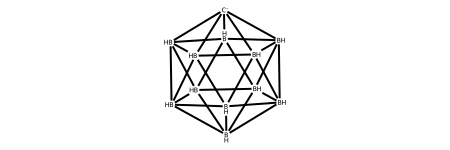

In [9]:

filename = '../data/AlexClarkStructures_v2/training.ds/mol_training.ds_25.mol'
filename = '../data/AlexClarkStructures_v2/stereochemistry.ds/mol_stereochemistry.ds_277.mol'
filename = '../data/AlexClarkStructures_v2/csd-selection.ds/mol_csd-selection.ds_169.mol'
filename = '../data/AlexClarkStructures_v2/csd-selection.ds/mol_csd-selection.ds_48.mol'
filename = '../data/AlexClarkStructures_v2/training.ds/mol_training.ds_87.mol'
filename = '../data/AlexClarkStructures_v1/alternating.ds/mol_alternating.ds_0.mol'

rd_mol = Chem.MolFromMolFile(filename)      
Chem.SanitizeMol(rd_mol)
Chem.AddHs(rd_mol)

conformer = rd_mol.GetConformer(0)

metal_atom = find_metal_atom(rd_mol)
if metal_atom is None:
    print("no metal")    
else:

    metal_atom_id = metal_atom.GetIdx()

    print(metal_atom.GetSymbol())
    metal_position = conformer.GetAtomPosition(metal_atom_id)
    print("metal coords", (metal_position.x, metal_position.y, metal_position.z))

    G = nx.Graph()

    G.add_node(metal_atom_id, 
            pos=(metal_position.x, metal_position.y, metal_position.z), 
            symbol=metal_atom.GetSymbol(), 
            atomic_num=metal_atom.GetAtomicNum())

    for neighbor_atom in metal_atom.GetNeighbors():
        atom_idx = neighbor_atom.GetIdx()
        cur_position = conformer.GetAtomPosition(atom_idx)
        print(neighbor_atom.GetSymbol(), (cur_position.x, cur_position.y, cur_position.z))
        
        G.add_node(atom_idx, 
                pos=(cur_position.x, cur_position.y, cur_position.z), 
                symbol=neighbor_atom.GetSymbol(), 
                atomic_num=neighbor_atom.GetAtomicNum())
        
        G.add_edge(metal_atom_id, atom_idx)

    # print(get_hull_counts(G))
    print(classify_metal_geometry(filename))

    # print(get_geometry_from_rdkit(filename))

rd_mol

In [ ]:
draw_3d_molecule_graph_plotly(G)

In [18]:
# folder path
dir_path = '../data/AlexClarkStructures_v2/'

tl_success = []
tl_failed = []
tl_failed_chem = []
tl_nometal = []
tl_unknown = []
count = 0
for path, subdirs, files in os.walk(dir_path):
    for name in files:
        cur_filename = os.path.join(path, name)
        count += 1                        
            
        geometry, metal_atom = classify_metal_geometry(cur_filename)
                
        # print(tmp_res)
        if "failed-chem" == geometry:
            tmp_res = ("", -1, geometry, cur_filename)
            
            tl_failed_chem.append(tmp_res)
        elif "failed" == geometry:
            tmp_res = ("", -1, geometry, cur_filename)
            
            tl_failed.append(tmp_res)
        elif "metal" in geometry:            
            tmp_res = ("", -1, geometry, cur_filename)
            # print(tmp_res)
            tl_nometal.append(tmp_res)
        else:
            tmp_res = (metal_atom.GetSymbol(), len(metal_atom.GetNeighbors()), geometry, cur_filename)    
            if "unknown" not in geometry:    
                tl_success.append(tmp_res)
            else:
                tl_unknown.append(tmp_res)            

# for uk_geo in tl_failed_chem:
#     # if "3" in uk_geo[2]:
#     print(uk_geo)

print("unique geometries", set([x[2] for x in tl_success]))
print("identified", len(tl_success))
print("unknown", len(tl_unknown))
print("mols failed", len(tl_failed))
print("mols failed chem", len(tl_failed_chem))
print("mols no metal", len(tl_nometal))
print("--> checked", len(tl_success)+len(tl_unknown)+len(tl_failed)+len(tl_failed_chem) +len(tl_nometal), "/", count)

unique geometries {'bent', 'square planar', 'trigonal planar', 'square antiprismatic', 'square pyramid', 'trigonal prismatic', 'octahedral', 'linear', '1-bond', 'no-bond', 'seesaw', 't shape', 'tetrahedral', 'dodecahedral'}
identified 1162
unknown 1377
mols failed 2287
mols failed chem 0
mols no metal 327
--> checked 5153 / 5153
